In [16]:
"""
Demonstrating my clustering wrapper based on Scikit-learn and cuML, with full GPU support
"""
import pandas as pd
import warnings
from ac.ml.clustering import ClusterMaker
warnings.filterwarnings("ignore")

In [17]:
"""
Loading a smaller version of my dataset containing all Tweets / Truth posts of the US Presidency (Obama to Trump 2).
For each message, sentiment analysis has already been performed to discover which kind of emotion the presidents express.
Emotion values range from 0 to 1.
"""
presidential = pd.read_csv("./data/small_presidential_tweets.csv")
presidential.fillna(value=0, inplace=True)
presidential.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2837 entries, 0 to 2836
Data columns (total 37 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      2837 non-null   int64  
 1   Author          2837 non-null   object 
 2   Social          2837 non-null   object 
 3   Id              2837 non-null   int64  
 4   Content         2837 non-null   object 
 5   Words           2837 non-null   object 
 6   Date            2837 non-null   object 
 7   Time            2837 non-null   object 
 8   Intensity       2837 non-null   float64
 9   anger           2837 non-null   float64
 10  fear            2837 non-null   float64
 11  disgust         2837 non-null   float64
 12  sadness         2837 non-null   float64
 13  joy             2837 non-null   float64
 14  surprise        2837 non-null   float64
 15  disapproval     2837 non-null   float64
 16  optimism        2837 non-null   float64
 17  nervousness     2837 non-null   f

In [18]:
"""
Let's pass the dataset to the ClusterMaker. We'll perform basic sentiment analysis. How do posts expressing
"admiration" and "gratitude" relate to each other? We'll use a Kmeans algorithm
"""
cm = ClusterMaker(
    method="kmeans",
    data=presidential,
    subset=["admiration", "gratitude"],
    scaling="minmax",
    random="50%",
    cpu=False
)

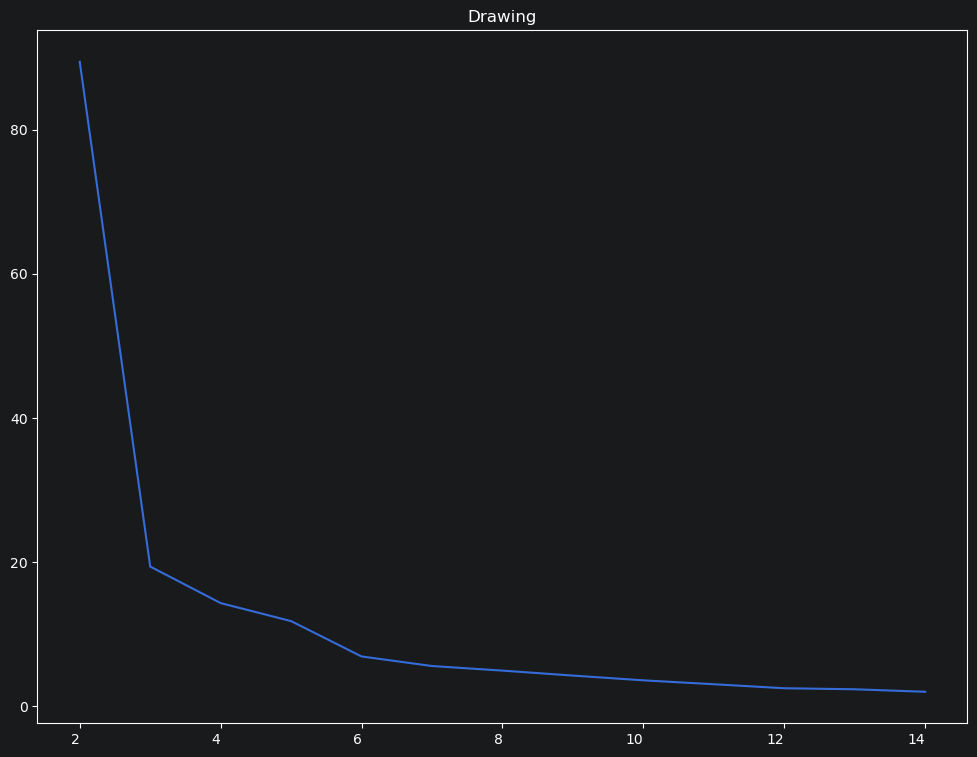

True

In [19]:
"""
Let's have a look to the SSE curve. It looks like the optimal n_clusters hyperparameter amounts to 3...
"""
cm.curve()
cm.draw(what="sse", show=True)

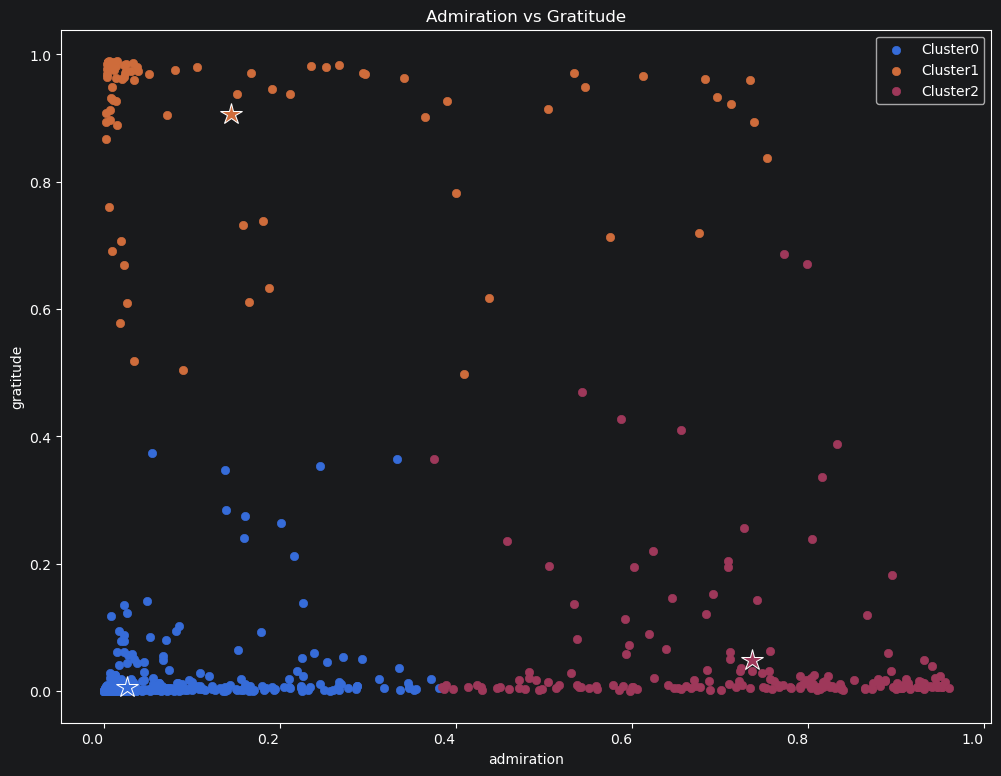

True

In [20]:
"""
We can let ClusterMaker choose the optimal hyperparameters automatically, though. Just launch the explore() method.
Then, just fit the data and plot the clustering.
"""
cm.explore()
cm.fit()
cm.draw(
    what="clustering",
    x="admiration",
    y="gratitude",
    centroids=True,
    show=True,
    title="Admiration vs Gratitude",
    xlabel="admiration",
    ylabel="gratitude",
)